In [1]:
%matplotlib inline

In [2]:
import torch
from matplotlib import pyplot as plt
from transformers import AutoProcessor, Blip2ForConditionalGeneration

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
"Using Device:", device

('Using Device:', device(type='cuda'))

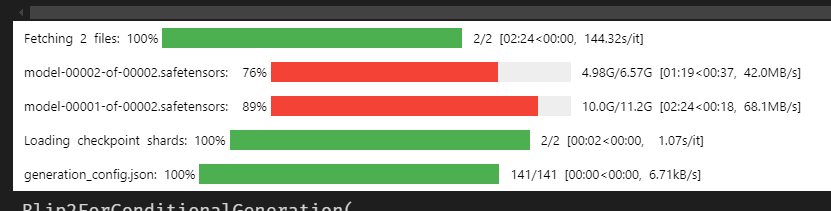

好佔空間啊~~~~~

In [4]:
MODEL_ID = "Salesforce/blip2-opt-2.7b"
## 這個模型需要大約 11GB 的顯存，硬碟空間約 18GB。
# 如果顯存不足，可以使用更小的模型，例如：
# MODEL_ID = "Salesforce/blip-image-captioning-base"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Blip2ForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
model.to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

In [5]:
import requests
from PIL import Image

!wget -q https://d1fufvy4xao6k9.cloudfront.net/images/blog/posts/2023/03/imagetools14.jpg -O MyImage.jpg
dest = 'MyImage.jpg'
image = Image.open(dest)

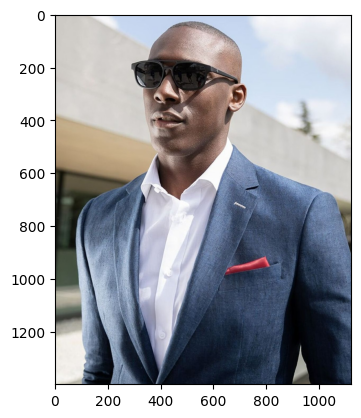

In [6]:
plt.imshow(image)
plt.show()

In [7]:
inputs = processor(image, return_tensors="pt").to(device, torch.float16)


generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)


a man in a suit and tie is standing in front of a building


In [8]:
prompt = "Question: what is the color of the man's shirt? Answer:"

inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=10)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)

Question: what is the color of the man's shirt? Answer: blue
